In [18]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/b24bb1040/12-language/12-way script classification dataset/train_1800/punjabi/J_image_217_29.jpg
/kaggle/input/datasets/b24bb1040/12-language/12-way script classification dataset/train_1800/punjabi/J_image_92_3.jpg
/kaggle/input/datasets/b24bb1040/12-language/12-way script classification dataset/train_1800/punjabi/J_image_171_23.jpg
/kaggle/input/datasets/b24bb1040/12-language/12-way script classification dataset/train_1800/punjabi/J_image_204_47.jpg
/kaggle/input/datasets/b24bb1040/12-language/12-way script classification dataset/train_1800/punjabi/J_image_374_15.jpg
/kaggle/input/datasets/b24bb1040/12-language/12-way script classification dataset/train_1800/punjabi/J_image_45_405.jpg
/kaggle/input/datasets/b24bb1040/12-language/12-way script classification dataset/train_1800/punjabi/J_image_406_14.jpg
/kaggle/input/datasets/b24bb1040/12-language/12-way script classification dataset/train_1800/punjabi/J_image_137_46.jpg
/kaggle/input/datasets/b24bb1040/12-langua

In [19]:
train_dir = '/kaggle/input/datasets/b24bb1040/12-language/12-way script classification dataset/train_1800'
test_dir  = '/kaggle/input/datasets/b24bb1040/12-language/12-way script classification dataset/test_478'

print("Train classes:", sorted(os.listdir(train_dir)))
print("Test classes :", sorted(os.listdir(test_dir)))

Train classes: ['assamese', 'bengali', 'english', 'gujarati', 'hindi', 'kannada', 'malayalam', 'marathi', 'odia', 'punjabi', 'tamil', 'telugu']
Test classes : ['assamese', 'bengali', 'english', 'gujarati', 'hindi', 'kannada', 'malayalam', 'marathi', 'odia', 'punjabi', 'tamil', 'telugu']


In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_hub
from sklearn.metrics import classification_report, confusion_matrix
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("GPU enabled:", gpus)
else:
    print("No GPU - go to Runtime > Change runtime type > T4 GPU")

print("TensorFlow:", tf.__version__)
print("Keras Hub :", keras_hub.__version__)

GPU enabled: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
TensorFlow: 2.19.0
Keras Hub : 0.21.1


In [21]:
from tensorflow.keras import mixed_precision

policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)
print("Mixed precision:", policy.name)

Mixed precision: mixed_float16


In [22]:
train_dir = '/kaggle/input/datasets/b24bb1040/12-language/12-way script classification dataset/train_1800'
test_dir  = '/kaggle/input/datasets/b24bb1040/12-language/12-way script classification dataset/test_478'

IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_CLASSES = 12
SEED        = 42
LR          = 1e-5

np.random.seed(SEED)
tf.random.set_seed(SEED)

In [23]:
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def build_dataset(data_dir, training=True):
    data_dir   = Path(data_dir)
    class_dirs = sorted([d for d in data_dir.iterdir() if d.is_dir()])
    cls_names  = [d.name for d in class_dirs]
    cls_to_idx = {name: idx for idx, name in enumerate(cls_names)}

    all_paths, all_labels = [], []

    for class_dir in class_dirs:
        label = cls_to_idx[class_dir.name]
        for img_path in class_dir.glob('*'):
            if img_path.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']:
                all_paths.append(str(img_path))
                all_labels.append(label)

    all_paths  = np.array(all_paths)
    all_labels = np.array(all_labels)

    idx        = np.random.permutation(len(all_paths))
    all_paths  = all_paths[idx]
    all_labels = all_labels[idx]

    if training:
        split      = int(0.9 * len(all_paths))
        tr_paths   = all_paths[:split]
        val_paths  = all_paths[split:]
        tr_labels  = all_labels[:split]
        val_labels = all_labels[split:]

        tr_labels_oh  = tf.keras.utils.to_categorical(tr_labels,  NUM_CLASSES)
        val_labels_oh = tf.keras.utils.to_categorical(val_labels, NUM_CLASSES)

        train_ds = (tf.data.Dataset.from_tensor_slices((tr_paths, tr_labels_oh))
                    .shuffle(len(tr_paths), seed=SEED)
                    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
                    .batch(BATCH_SIZE)
                    .prefetch(AUTOTUNE))

        val_ds   = (tf.data.Dataset.from_tensor_slices((val_paths, val_labels_oh))
                    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
                    .batch(BATCH_SIZE)
                    .prefetch(AUTOTUNE))

        return train_ds, val_ds, cls_names, tr_labels, val_labels

    else:
        labels_oh = tf.keras.utils.to_categorical(all_labels, NUM_CLASSES)

        test_ds  = (tf.data.Dataset.from_tensor_slices((all_paths, labels_oh))
                    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
                    .batch(BATCH_SIZE)
                    .prefetch(AUTOTUNE))

        return test_ds, cls_names, all_labels


train_ds, val_ds, class_names, train_labels, val_labels = build_dataset(train_dir, training=True)
test_ds,  _,      true_labels                           = build_dataset(test_dir,  training=False)

print("Classes    :", class_names)
print("Train size :", len(train_labels))
print("Val size   :", len(val_labels))
print("Test size  :", len(true_labels))
print("Train steps:", len(train_labels) // BATCH_SIZE)

Classes    : ['assamese', 'bengali', 'english', 'gujarati', 'hindi', 'kannada', 'malayalam', 'marathi', 'odia', 'punjabi', 'tamil', 'telugu']
Train size : 19440
Val size   : 2160
Test size  : 5736
Train steps: 607


In [24]:
backbone = keras_hub.models.ViTBackbone.from_preset(
    "vit_base_patch16_224_imagenet"
)

backbone.trainable = False
print("Pretrained ViT backbone loaded and frozen")

Pretrained ViT backbone loaded and frozen


In [25]:
def build_model(learning_rate=LR, dropout=0.3, trainable_backbone=False, l2_reg=1e-4):

    backbone.trainable = trainable_backbone

    inputs    = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x         = backbone(inputs, training=False)

    # CLS token at index 0
    cls_token = x[:, 0, :]

    x = layers.LayerNormalization()(cls_token)
    x = layers.Dense(512, activation='gelu', kernel_regularizer=keras.regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(256, activation='gelu', kernel_regularizer=keras.regularizers.l2(l2_reg))(x)
    x = layers.Dropout(dropout * 0.5)(x)

    # float32 for mixed precision stability
    outputs = layers.Dense(NUM_CLASSES, activation='softmax', dtype='float32', kernel_regularizer=keras.regularizers.l2(l2_reg))(x)

    model = keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


model = build_model()
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vi_t_backbone (ViTBackbone)     │ (None, 197, 768)       │    85,798,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ get_item_1 (GetItem)            │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 768)            │         1,536 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 12)             │         3,084 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 86,330,380 (329.32 MB)

 Trainable params: 530,700 (2.02 MB)

 Non-trainable params: 85,799,680 (327.30 MB)

In [26]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

def get_callbacks(name):
    return [
        EarlyStopping(
            monitor='val_accuracy',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        ModelCheckpoint(
            name,
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-8,
            verbose=1
        )
    ]

print("Callbacks ready")

Callbacks ready


In [27]:
print("Phase 1: Training classification head only")
print("=" * 55)

history1 = model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    callbacks=get_callbacks('phase1_best.keras'),
    verbose=1
)

print(f"\nPhase 1 best val accuracy: {max(history1.history['val_accuracy'])*100:.2f}%")


Phase 1: Training classification head only
Epoch 1/10
608/608 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.1025 - loss: 3.2277
Epoch 1: val_accuracy improved from -inf to 0.18519, saving model to phase1_best.keras
608/608 ━━━━━━━━━━━━━━━━━━━━ 100s 137ms/step - accuracy: 0.1026 - loss: 3.2275 - val_accuracy: 0.1852 - val_loss: 2.4957 - learning_rate: 1.0000e-05
Epoch 2/10
608/608 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.1661 - loss: 2.7025
Epoch 2: val_accuracy improved from 0.18519 to 0.27870, saving model to phase1_best.keras
608/608 ━━━━━━━━━━━━━━━━━━━━ 72s 118ms/step - accuracy: 0.1661 - loss: 2.7024 - val_accuracy: 0.2787 - val_loss: 2.2159 - learning_rate: 1.0000e-05
Epoch 3/10
608/608 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.2396 - loss: 2.4023
Epoch 3: val_accuracy improved from 0.27870 to 0.33148, saving model to phase1_best.keras
608/608 ━━━━━━━━━━━━━━━━━━━━ 71s 116ms/step - accuracy: 0.2397 - loss: 2.4022 - val_accuracy: 0.3315 - val_loss: 2.0467 - learnin

In [28]:
print("Phase 2: Fine-tuning backbone last layers")
print("=" * 55)

configs = [
    {'lr': 1e-5, 'dropout': 0.50, 'trainable': True},
    {'lr': 1e-5, 'dropout': 0.45, 'trainable': True},
]

best_val_acc = 0
best_config = None
results = []   # ✅ FIX

for i, cfg in enumerate(configs):
    print(f"\nConfig {i+1}: {cfg}")
    print("-" * 45)

    model = keras.models.load_model('phase1_best.keras')

    for layer in model.layers:
        layer.trainable = True

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=cfg['lr']),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history2 = model.fit(
        train_ds,
        epochs=7,
        validation_data=val_ds,
        callbacks=get_callbacks(f'phase2_config{i+1}_best.keras'),
        verbose=1
    )

    val_acc = max(history2.history['val_accuracy'])
    print(f"\nConfig {i+1} best val accuracy: {val_acc*100:.2f}%")

    # ✅ STORE results
    results.append({
        'model': model,
        'val_acc': val_acc,
        'config': cfg,
        'config_idx': i + 1
    })

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_config = cfg
        best_config_idx = i + 1

# ✅ Get best model
best = max(results, key=lambda x: x['val_acc'])
best_model = best['model']

print("\n" + "=" * 55)
print(f"Best config: Config {best_config_idx} → {best_config}")
print(f"Best Phase 2 val accuracy: {best_val_acc*100:.2f}%")

Phase 2: Fine-tuning backbone last layers

Config 1: {'lr': 1e-05, 'dropout': 0.5, 'trainable': True}
---------------------------------------------
Epoch 1/7
608/608 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.5263 - loss: 1.4639
Epoch 1: val_accuracy improved from -inf to 0.68843, saving model to phase2_config1_best.keras
608/608 ━━━━━━━━━━━━━━━━━━━━ 345s 480ms/step - accuracy: 0.5264 - loss: 1.4637 - val_accuracy: 0.6884 - val_loss: 0.9840 - learning_rate: 1.0000e-05
Epoch 2/7
608/608 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - accuracy: 0.6872 - loss: 0.9753
Epoch 2: val_accuracy improved from 0.68843 to 0.75741, saving model to phase2_config1_best.keras
608/608 ━━━━━━━━━━━━━━━━━━━━ 263s 433ms/step - accuracy: 0.6872 - loss: 0.9752 - val_accuracy: 0.7574 - val_loss: 0.7935 - learning_rate: 1.0000e-05
Epoch 3/7
608/608 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accuracy: 0.7795 - loss: 0.7326
Epoch 3: val_accuracy improved from 0.75741 to 0.79769, saving model to phase2_config1_best.keras
60

180/180 ━━━━━━━━━━━━━━━━━━━━ 22s 120ms/step - accuracy: 0.7672 - loss: 0.8508

Final Test Accuracy: 76.92%
180/180 ━━━━━━━━━━━━━━━━━━━━ 26s 123ms/step

Final Class-wise Accuracy:
-----------------------------------
  assamese            : 76.15%
  bengali             : 70.08%
  english             : 82.43%
  gujarati            : 88.91%
  hindi               : 71.97%
  kannada             : 77.20%
  malayalam           : 80.75%
  marathi             : 55.65%
  odia                : 89.75%
  punjabi             : 83.47%
  tamil               : 69.67%
  telugu              : 76.99%
-----------------------------------
  Mean Accuracy: 76.92%

Full Classification Report:
              precision    recall  f1-score   support

    assamese     0.7413    0.7615    0.7513       478
     bengali     0.7957    0.7008    0.7453       478
     english     0.7944    0.8243    0.8090       478
    gujarati     0.7741    0.8891    0.8277       478
       hindi     0.6067    0.7197    0.6584       478

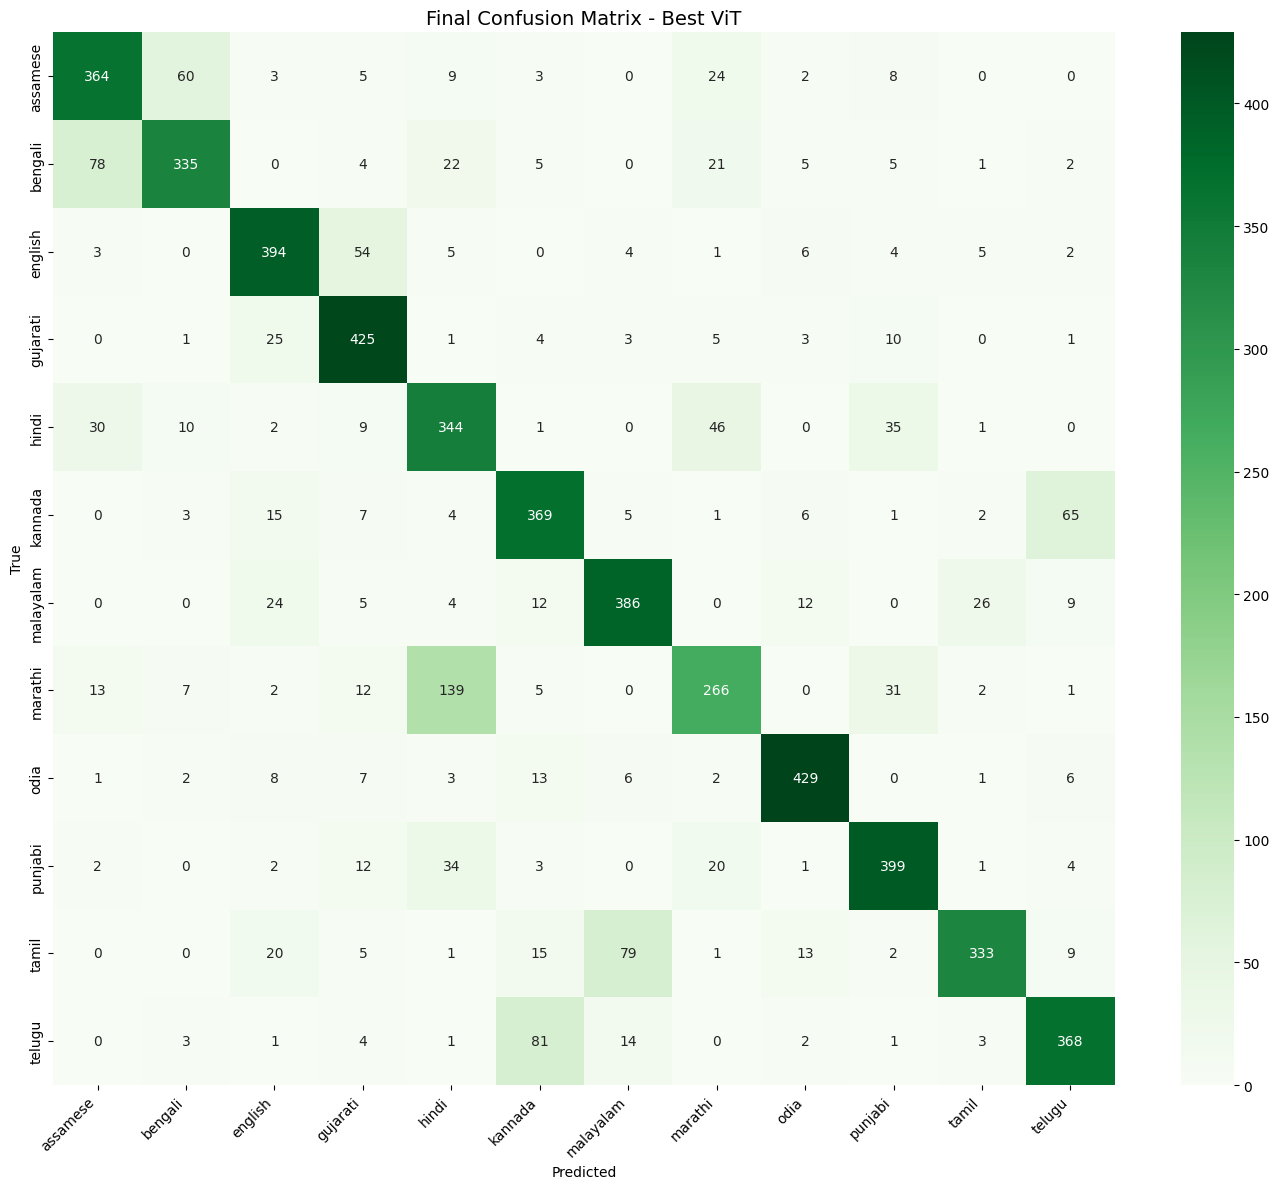

In [29]:
test_loss, test_acc = best_model.evaluate(test_ds, verbose=1)
print(f"\nFinal Test Accuracy: {test_acc*100:.2f}%")

y_pred_final = np.argmax(best_model.predict(test_ds, verbose=1), axis=1)
y_true_final = true_labels

cm_final    = confusion_matrix(y_true_final, y_pred_final)
class_acc_f = cm_final.diagonal() / cm_final.sum(axis=1)

print("\nFinal Class-wise Accuracy:")
print("-" * 35)
for name, acc in zip(class_names, class_acc_f):
    print(f"  {name:20s}: {acc*100:.2f}%")
print("-" * 35)
print(f"  Mean Accuracy: {class_acc_f.mean()*100:.2f}%")

print("\nFull Classification Report:")
print(classification_report(y_true_final, y_pred_final, target_names=class_names, digits=4))

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm_final,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Final Confusion Matrix - Best ViT', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('final_confusion_matrix.png', dpi=150)
plt.show()